In [1]:
# ============================================
# Task 1: Data Exploration and Enrichment
# Forecasting Financial Inclusion in Ethiopia
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)

# Plot style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================
# Project Paths
# ============================================

PROJECT_ROOT = Path("../")

RAW_DATA = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"

print("Raw Data Folder :", RAW_DATA)
print("Processed Folder :", PROCESSED_DATA)

Raw Data Folder : ..\data\raw
Processed Folder : ..\data\processed


In [4]:
# ============================================
# Load Datasets
# ============================================

fi_data = pd.read_csv(RAW_DATA / "ethiopia_fi_unified_data.xlsx - ethiopia_fi_unified_data.csv")

reference_codes = pd.read_csv(RAW_DATA / "reference_codes.xlsx - reference_codes.csv")

print("Financial Inclusion Dataset Shape :", fi_data.shape)
print("Reference Codes Shape :", reference_codes.shape)

Financial Inclusion Dataset Shape : (43, 34)
Reference Codes Shape : (71, 4)


In [5]:
# ============================================
# First Five Rows
# ============================================

fi_data.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaN,NaN,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globalfindex,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaN,NaN,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globalfindex,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globalfindex,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globalfindex,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globalfindex,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


In [6]:
reference_codes.head()

,field,code,description,applies_to
0,record_type,observation,Actual measured value from a source,All
1,record_type,event,Policy launch market event or milestone,All
2,record_type,impact_link,Relationship between event and indicator (links via parent_id),All
3,record_type,target,Policy target or official goal,All
4,record_type,baseline,Starting point for comparison,All


In [7]:
print(f"Rows    : {fi_data.shape[0]}")
print(f"Columns : {fi_data.shape[1]}")

Rows    : 43
Columns : 34


In [8]:
print("Columns in Dataset:\n")

for col in fi_data.columns:
    print(col)

Columns in Dataset:

record_id
record_type
category
pillar
indicator
indicator_code
indicator_direction
value_numeric
value_text
value_type
unit
observation_date
period_start
period_end
fiscal_year
gender
location
region
source_name
source_type
source_url
confidence
related_indicator
relationship_type
impact_direction
impact_magnitude
impact_estimate
lag_months
evidence_basis
comparable_country
collected_by
collection_date
original_text
notes


In [9]:
# ============================================
# Missing Values
# ============================================

missing = fi_data.isnull().sum().sort_values(ascending=False)

missing

lag_months             43
region                 43
impact_estimate        43
relationship_type      43
evidence_basis         43
notes                  43
related_indicator      43
impact_magnitude       43
impact_direction       43
category               33
period_start           33
collection_date        33
period_end             33
value_text             33
source_url             12
indicator_direction    10
pillar                 10
value_numeric          10
original_text          10
unit                   10
record_type             0
record_id               0
indicator_code          0
indicator               0
value_type              0
observation_date        0
location                0
gender                  0
fiscal_year             0
confidence              0
source_type             0
source_name             0
comparable_country      0
collected_by            0
dtype: int64

In [ ]:
#Dataset Dimensions
print(f"Rows    : {fi_data.shape[0]}")
print(f"Columns : {fi_data.shape[1]}")

Rows    : 43
Columns : 34


In [ ]:
#Missing Values Percentage
missing_percent = (
    fi_data.isnull()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

missing_percent

lag_months             100.00
region                 100.00
impact_estimate        100.00
relationship_type      100.00
evidence_basis         100.00
notes                  100.00
related_indicator      100.00
impact_magnitude       100.00
impact_direction       100.00
category                76.74
period_start            76.74
collection_date         76.74
period_end              76.74
value_text              76.74
source_url              27.91
indicator_direction     23.26
pillar                  23.26
value_numeric           23.26
original_text           23.26
unit                    23.26
record_type              0.00
record_id                0.00
indicator_code           0.00
indicator                0.00
value_type               0.00
observation_date         0.00
location                 0.00
gender                   0.00
fiscal_year              0.00
confidence               0.00
source_type              0.00
source_name              0.00
comparable_country       0.00
collected_

In [13]:
#Duplicate Records
duplicates = fi_data.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [14]:
#Summary Statistics
fi_data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
record_id,43,43,REC_0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
record_type,43,3,observation,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,10,7,product_launch,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pillar,33,4,ACCESS,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indicator,43,29,Account Ownership Rate,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indicator_code,43,29,ACC_OWNERSHIP,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indicator_direction,33,3,higher_better,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
value_numeric,33.0,NaN,NaN,NaN,94372576990.694839,423106092501.167664,1.08,24.0,61.4,15000000.0,2380000000000.0
value_text,10,3,Launched,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
value_type,43,6,percentage,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
#Record Types
record_counts = fi_data["record_type"].value_counts()

record_counts

record_type
observation    30
event          10
target          3
Name: count, dtype: int64

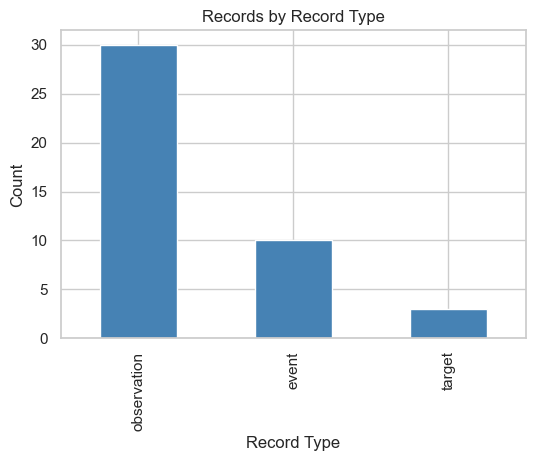

In [16]:
#Plot Record Types
plt.figure(figsize=(6,4))

record_counts.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Records by Record Type")
plt.xlabel("Record Type")
plt.ylabel("Count")

plt.show()

In [17]:
#Pillar Distribution
fi_data["pillar"].value_counts(dropna=False)

pillar
ACCESS           16
USAGE            11
NaN              10
GENDER            5
AFFORDABILITY     1
Name: count, dtype: int64

In [18]:
#Source Type Distribution
fi_data["source_type"].value_counts(dropna=False)

source_type
operator      15
survey        10
regulator      7
research       4
policy         3
calculated     2
news           2
Name: count, dtype: int64

In [20]:
#Confidence Levels
fi_data["confidence"].value_counts(dropna=False)

confidence
high      40
medium     3
Name: count, dtype: int64

In [21]:
#Convert Date Columns
fi_data["observation_date"] = pd.to_datetime(
    fi_data["observation_date"],
    errors="coerce"
)

In [22]:
#Temporal Coverage
print("Earliest Date :", fi_data["observation_date"].min())
print("Latest Date   :", fi_data["observation_date"].max())

Earliest Date : 2014-12-31 00:00:00
Latest Date   : 2030-12-31 00:00:00


In [23]:
#Extract Year
fi_data["year"] = fi_data["observation_date"].dt.year

In [24]:
#Records Per Year
fi_data["year"].value_counts().sort_index()

year
2014     1
2017     1
2021     7
2022     1
2023     2
2024    14
2025    15
2028     1
2030     1
Name: count, dtype: int64

In [25]:
#Indicator Coverage
indicator_summary = (
    fi_data.groupby("indicator_code")
           .size()
           .sort_values(ascending=False)
)

indicator_summary

indicator_code
ACC_OWNERSHIP         7
ACC_FAYDA             4
ACC_4G_COV            2
ACC_MM_ACCOUNT        2
GEN_GAP_ACC           2
GEN_MM_SHARE          2
USG_P2P_COUNT         2
AFF_DATA_INCOME       1
EVT_FAYDA             1
EVT_FX_REFORM         1
EVT_CROSSOVER         1
EVT_ETHIOPAY          1
ACC_MOBILE_PEN        1
EVT_NFIS2             1
EVT_MPESA_INTEROP     1
EVT_MPESA             1
EVT_SAFCOM_PRICE      1
EVT_TELEBIRR          1
GEN_GAP_MOBILE        1
USG_ACTIVE_RATE       1
EVT_SAFARICOM         1
USG_ATM_COUNT         1
USG_ATM_VALUE         1
USG_MPESA_ACTIVE      1
USG_CROSSOVER         1
USG_MPESA_USERS       1
USG_P2P_VALUE         1
USG_TELEBIRR_USERS    1
USG_TELEBIRR_VALUE    1
dtype: int64

In [26]:
#Unique Indicators
fi_data["indicator_code"].unique()

<StringArray>
[     'ACC_OWNERSHIP',     'ACC_MM_ACCOUNT',         'ACC_4G_COV',
     'ACC_MOBILE_PEN',          'ACC_FAYDA',      'USG_P2P_COUNT',
      'USG_P2P_VALUE',      'USG_ATM_COUNT',      'USG_ATM_VALUE',
      'USG_CROSSOVER', 'USG_TELEBIRR_USERS', 'USG_TELEBIRR_VALUE',
    'USG_MPESA_USERS',   'USG_MPESA_ACTIVE',    'USG_ACTIVE_RATE',
    'AFF_DATA_INCOME',        'GEN_GAP_ACC',       'GEN_MM_SHARE',
     'GEN_GAP_MOBILE',       'EVT_TELEBIRR',      'EVT_SAFARICOM',
          'EVT_MPESA',          'EVT_FAYDA',      'EVT_FX_REFORM',
      'EVT_CROSSOVER',  'EVT_MPESA_INTEROP',       'EVT_ETHIOPAY',
          'EVT_NFIS2',   'EVT_SAFCOM_PRICE']
Length: 29, dtype: str

In [28]:
#Explore Events
events = fi_data[
    fi_data["record_type"] == "event"
]

events.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year
33,EVT_0001,event,product_launch,NaN,Telebirr Launch,EVT_TELEBIRR,NaN,NaN,Launched,categorical,NaN,2021-05-17,NaN,NaN,2021,all,national,NaN,Ethio Telecom,operator,https://www.ethiotelecom.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,First major mobile money service in Ethiopia,NaN,2021
34,EVT_0002,event,market_entry,NaN,Safaricom Ethiopia Commercial Launch,EVT_SAFARICOM,NaN,NaN,Launched,categorical,NaN,2022-08-01,NaN,NaN,2022,all,national,NaN,News,news,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,End of state telecom monopoly,NaN,2022
35,EVT_0003,event,product_launch,NaN,M-Pesa Ethiopia Launch,EVT_MPESA,NaN,NaN,Launched,categorical,NaN,2023-08-01,NaN,NaN,2023,all,national,NaN,Safaricom,operator,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Second mobile money entrant,NaN,2023
36,EVT_0004,event,infrastructure,NaN,Fayda Digital ID Program Rollout,EVT_FAYDA,NaN,NaN,Launched,categorical,NaN,2024-01-01,NaN,NaN,2024,all,national,NaN,NIDP,regulator,https://www.id.gov.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,National biometric digital ID system,NaN,2024
37,EVT_0005,event,policy,NaN,Foreign Exchange Liberalization,EVT_FX_REFORM,NaN,NaN,Implemented,categorical,NaN,2024-07-29,NaN,NaN,2024,all,national,NaN,NBE,regulator,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Birr float introduced,NaN,2024


In [30]:
#Event Categories
events["category"].value_counts()

category
product_launch    2
infrastructure    2
policy            2
market_entry      1
milestone         1
partnership       1
pricing           1
Name: count, dtype: int64

In [32]:
#Events Timeline
events = events.sort_values("observation_date")

events[
    [
        "observation_date",
        "category",
        "indicator",
        "source_name"
    ]
]

,observation_date,category,indicator,source_name
33,2021-05-17,product_launch,Telebirr Launch,Ethio Telecom
41,2021-09-01,policy,NFIS-II Strategy Launch,NBE
34,2022-08-01,market_entry,Safaricom Ethiopia Commercial Launch,News
35,2023-08-01,product_launch,M-Pesa Ethiopia Launch,Safaricom
36,2024-01-01,infrastructure,Fayda Digital ID Program Rollout,NIDP
37,2024-07-29,policy,Foreign Exchange Liberalization,NBE
38,2024-10-01,milestone,P2P Transaction Count Surpasses ATM,EthSwitch
39,2025-10-27,partnership,M-Pesa EthSwitch Integration,EthSwitch
42,2025-12-15,pricing,Safaricom Ethiopia Price Increase,News
40,2025-12-18,infrastructure,EthioPay Instant Payment System Launch,NBE/EthSwitch


In [34]:
#Explore Impact Links
impact_links = fi_data[
    fi_data["record_type"] == "impact_link"
]

impact_links.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year


In [35]:
#Target Records
targets = fi_data[
    fi_data["record_type"] == "target"
]

targets

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year
30,REC_0031,target,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,70.0,NaN,percentage,%,2025-12-31,NaN,NaN,2025,all,national,NaN,NFIS-II Strategy,policy,https://nbe.gov.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NFIS-II target,NaN,2025
31,REC_0032,target,NaN,ACCESS,Fayda Digital ID Enrollment,ACC_FAYDA,higher_better,90000000.0,NaN,count,people,2028-12-31,NaN,NaN,2028,all,national,NaN,Fayda/NIDP,policy,https://www.id.gov.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,90M by 2028 target,NaN,2028
32,REC_0033,target,NaN,GENDER,Female Mobile Money Account Share,GEN_MM_SHARE,higher_better,50.0,NaN,percentage,%,2030-12-31,NaN,NaN,2030,female,national,NaN,NBE,policy,NaN,medium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Parity target,NaN,2030


In [36]:
#Save a Clean Copy
fi_data.to_csv(
    PROCESSED_DATA / "ethiopia_fi_clean.csv",
    index=False
)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.
